Running the block below, we ensure the modules are working well together and with the right version.

In [1]:
import numpy as np
import tensorflow as tf
import skimage
import pywt
import scipy


print(f"✅ NumPy: {np.__version__} (Compatible con TF)")
print(f"✅ Skimage: {skimage.__version__}")
print(f"✅ SciPy: {scipy.__version__}")
print(f"🚀 GPU: {tf.config.list_physical_devices('GPU')}")

2026-05-08 01:14:44.754010: I tensorflow/core/util/port.cc:110] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-05-08 01:14:45.011171: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-05-08 01:14:45.919169: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT


✅ NumPy: 1.23.5 (Compatible con TF)
✅ Skimage: 0.20.0
✅ SciPy: 1.10.1
🚀 GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


2026-05-08 01:14:47.872024: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:982] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2026-05-08 01:14:48.045787: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:982] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2026-05-08 01:14:48.045844: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:982] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.


We run next block for ensuring WSL uses just the necessary and avoid getting the PC out of memory for background apps.

In [2]:
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
    except RuntimeError as e:
        print(e)

# SEED Dataset

From: https://www.kaggle.com/datasets/sumairaziz/seed-power-quality-disturbance-dataset

Once we create a folder, we add all the .csv files.
Then we proceed to:
1. Apply Continuous Wavelet Transform
2. Normalize mathematically to 0-255
3. Resize to 128x128
4. Apply the 'jet' colormap to create a 3-channel RGB image
5. Save the image

In [ ]:
import os
import numpy as np
import pandas as pd
import pywt
import cv2

def process_seed_dataset_raw(csv_folder="SEED_CSV_Data", output_dir="seed_spectrograms_raw"):
    """
    Reads the 17 SEED dataset CSV files, applies standard CWT, 
    and saves them as raw RGB images with the 'jet' colormap (No CLAHE).
    """
    classes = [
        "Pure_Sinusoidal", "Sag", "Swell", "Interruption", "Transient", 
        "Oscillatory_Transient", "Harmonics", "Harmonics_with_Sag", 
        "Harmonics_with_Swell", "Flicker", "Flicker_with_Sag", 
        "Flicker_with_Swell", "Sag_with_Oscillatory_Transient", 
        "Swell_with_Oscillatory_Transient", "Sag_with_Harmonics", 
        "Swell_with_Harmonics", "Notch"
    ]
    
    for cls_name in classes:
        os.makedirs(os.path.join(output_dir, cls_name), exist_ok=True)
        
    print(f"Generating RAW SEED Spectrograms in: {os.path.abspath(output_dir)}")
    
    scales = np.arange(1, 128)
    wavelet = 'cmor'
    target_size = (128, 128)
    
    for class_idx, class_name in enumerate(classes):
        csv_path = os.path.join(csv_folder, f"{class_name}.csv")
        
        if not os.path.exists(csv_path):
            print(f"Warning: Could not find {csv_path}. Skipping.")
            continue
            
        print(f"Processing Class {class_idx + 1}/17: {class_name}...")
        df = pd.read_csv(csv_path, header=None)
        signals = df.values
        
        for i in range(len(signals)):
            signal = signals[i]
            
            # 1. Apply CWT
            coeffs, _ = pywt.cwt(signal, scales, wavelet)
            power = np.abs(coeffs)**2
            
            # 2. Normalize mathematically to 0-255
            power_scaled = cv2.normalize(power, None, 0, 255, cv2.NORM_MINMAX, dtype=cv2.CV_8U)
            
            # 3. Resize to 128x128
            power_resized = cv2.resize(power_scaled, target_size, interpolation=cv2.INTER_CUBIC)
            
            # 4. Apply the 'jet' colormap to create a 3-channel RGB image
            power_color = cv2.applyColorMap(power_resized, cv2.COLORMAP_JET)
            
            # 5. Save the raw image
            filename = os.path.join(output_dir, class_name, f"{class_name}_{i:04d}.png")
            cv2.imwrite(filename, power_color)

    print("\nRaw SEED Dataset generation completely successfully!")

if __name__ == "__main__":
    process_seed_dataset_raw()

Generating RAW SEED Spectrograms in: /mnt/c/py/ArtificialVision/seed_spectrograms_raw
Processing Class 1/17: Pure_Sinusoidal...


/home/mauro_wsl/miniconda3/envs/vision_gpu/lib/python3.10/site-packages/pywt/_cwt.py:117: FutureWarning: Wavelets from the family cmor, without parameters specified in the name are deprecated. The name should follow the format cmorB-C, where B and C are floats representing the bandwidth frequency and center frequency, respectively (example, for backward compatibility: cmor = cmor1.0-0.5).
  wavelet = DiscreteContinuousWavelet(wavelet)


Processing Class 2/17: Sag...


/home/mauro_wsl/miniconda3/envs/vision_gpu/lib/python3.10/site-packages/pywt/_cwt.py:117: FutureWarning: Wavelets from the family cmor, without parameters specified in the name are deprecated. The name should follow the format cmorB-C, where B and C are floats representing the bandwidth frequency and center frequency, respectively (example, for backward compatibility: cmor = cmor1.0-0.5).
  wavelet = DiscreteContinuousWavelet(wavelet)


Processing Class 3/17: Swell...


...

Processing Class 16/17: Swell_with_Harmonics...


/home/mauro_wsl/miniconda3/envs/vision_gpu/lib/python3.10/site-packages/pywt/_cwt.py:117: FutureWarning: Wavelets from the family cmor, without parameters specified in the name are deprecated. The name should follow the format cmorB-C, where B and C are floats representing the bandwidth frequency and center frequency, respectively (example, for backward compatibility: cmor = cmor1.0-0.5).
  wavelet = DiscreteContinuousWavelet(wavelet)


Processing Class 17/17: Notch...


/home/mauro_wsl/miniconda3/envs/vision_gpu/lib/python3.10/site-packages/pywt/_cwt.py:117: FutureWarning: Wavelets from the family cmor, without parameters specified in the name are deprecated. The name should follow the format cmorB-C, where B and C are floats representing the bandwidth frequency and center frequency, respectively (example, for backward compatibility: cmor = cmor1.0-0.5).
  wavelet = DiscreteContinuousWavelet(wavelet)



Raw SEED Dataset generation completely successfully!


# Training the 17-Class CNN

Now we train using the generated 2D dataset.

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models
import numpy as np
from sklearn.metrics import classification_report

# 1. Dataset Configuration
batch_size = 32
img_height = 128
img_width = 128
data_dir = "seed_spectrograms_raw" # Pointing to the RAW images

print("Loading RAW SEED datasets...")
# Load as standard RGB (3 channels)
train_ds = tf.keras.utils.image_dataset_from_directory(
  data_dir,
  validation_split=0.2,
  subset="training",
  seed=123,
  color_mode='rgb', # Standard RGB
  image_size=(img_height, img_width),
  batch_size=batch_size)

val_ds = tf.keras.utils.image_dataset_from_directory(
  data_dir,
  validation_split=0.2,
  subset="validation",
  seed=123,
  color_mode='rgb', # Standard RGB
  image_size=(img_height, img_width),
  batch_size=batch_size)

class_names = train_ds.class_names

# Standard optimization (No SpecAugment mapped here)
AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)

# 2. Standard CNN Architecture
model = models.Sequential([
  # Input is now 3 channels (RGB)
  layers.Rescaling(1./255, input_shape=(img_height, img_width, 3)),
  
  layers.Conv2D(32, 3, padding='same', activation='relu'),
  layers.MaxPooling2D(),
  
  layers.Conv2D(64, 3, padding='same', activation='relu'),
  layers.MaxPooling2D(),
  
  layers.Conv2D(128, 3, padding='same', activation='relu'),
  layers.MaxPooling2D(),
  
  layers.Flatten(),
  layers.Dense(256, activation='relu'),
  layers.Dropout(0.4),
  layers.Dense(17) # 17 Classes
])

model.compile(optimizer='adam',
              loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
              metrics=['accuracy'])

# 3. Train the Network
epochs = 25
history = model.fit(train_ds, validation_data=val_ds, epochs=epochs)

# 4. Evaluation
y_true = np.concatenate([y for x, y in val_ds], axis=0)
predictions = model.predict(val_ds)
y_pred = np.argmax(predictions, axis=1)

print("\n--- RAW Baseline CNN Results ---")
print(classification_report(y_true, y_pred, target_names=class_names))

Loading RAW SEED datasets...
Found 17000 files belonging to 17 classes.
Using 13600 files for training.
Found 17000 files belonging to 17 classes.
Using 3400 files for validation.
Epoch 1/25


2026-03-14 20:08:50.219890: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'Placeholder/_0' with dtype string and shape [13600]
	 [[{{node Placeholder/_0}}]]
2026-03-14 20:08:50.220144: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'Placeholder/_0' with dtype string and shape [13600]
	 [[{{node Placeholder/_0}}]]


424/425 [============================>.] - ETA: 0s - loss: 2.1360 - accuracy: 0.2714

2026-03-14 20:09:07.313579: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'Placeholder/_0' with dtype string and shape [3400]
	 [[{{node Placeholder/_0}}]]
2026-03-14 20:09:07.313824: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'Placeholder/_4' with dtype int32 and shape [3400]
	 [[{{node Placeholder/_4}}]]


425/425 [==============================] - 18s 25ms/step - loss: 2.1354 - accuracy: 0.2717 - val_loss: 1.7843 - val_accuracy: 0.3650
Epoch 2/25
425/425 [==============================] - 10s 24ms/step - loss: 1.7801 - accuracy: 0.3549 - val_loss: 1.5924 - val_accuracy: 0.4071
Epoch 3/25
425/425 [==============================] - 12s 28ms/step - loss: 1.6382 - accuracy: 0.3963 - val_loss: 1.4593 - val_accuracy: 0.4494
Epoch 4/25
425/425 [==============================] - 10s 24ms/step - loss: 1.4913 - accuracy: 0.4521 - val_loss: 1.2644 - val_accuracy: 0.5365
Epoch 5/25
425/425 [==============================] - 10s 23ms/step - loss: 1.3218 - accuracy: 0.5176 - val_loss: 1.1294 - val_accuracy: 0.5850
Epoch 6/25
425/425 [==============================] - 10s 23ms/step - loss: 1.1832 - accuracy: 0.5707 - val_loss: 1.0165 - val_accuracy: 0.6421
Epoch 7/25
425/425 [==============================] - 12s 28ms/step - loss: 1.1072 - accuracy: 0.5988 - val_loss: 0.9962 - val_accuracy: 0.6571
Epo

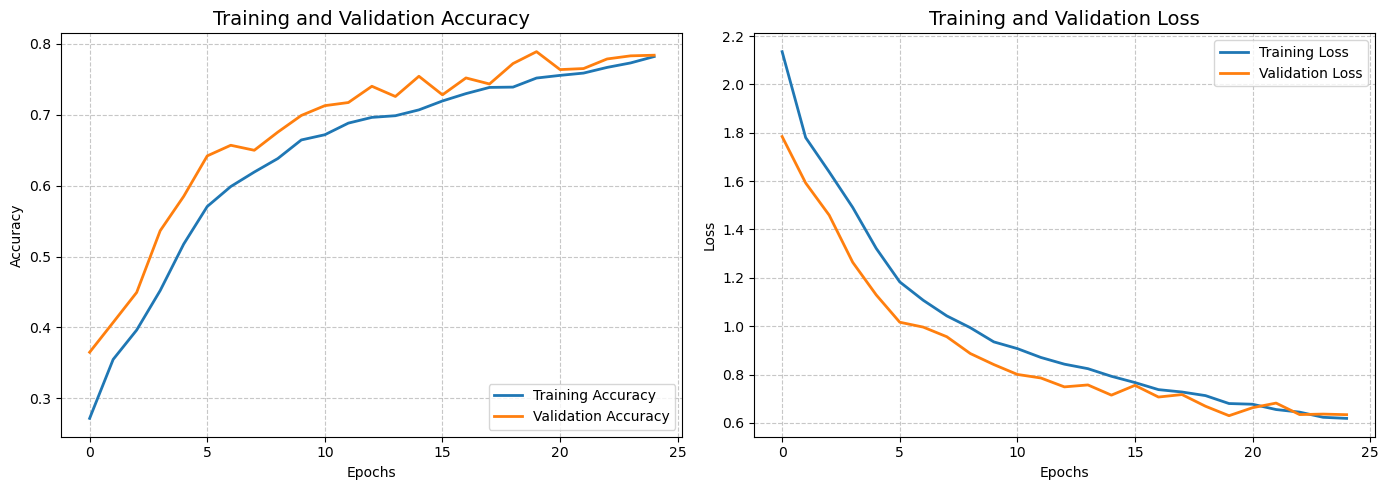

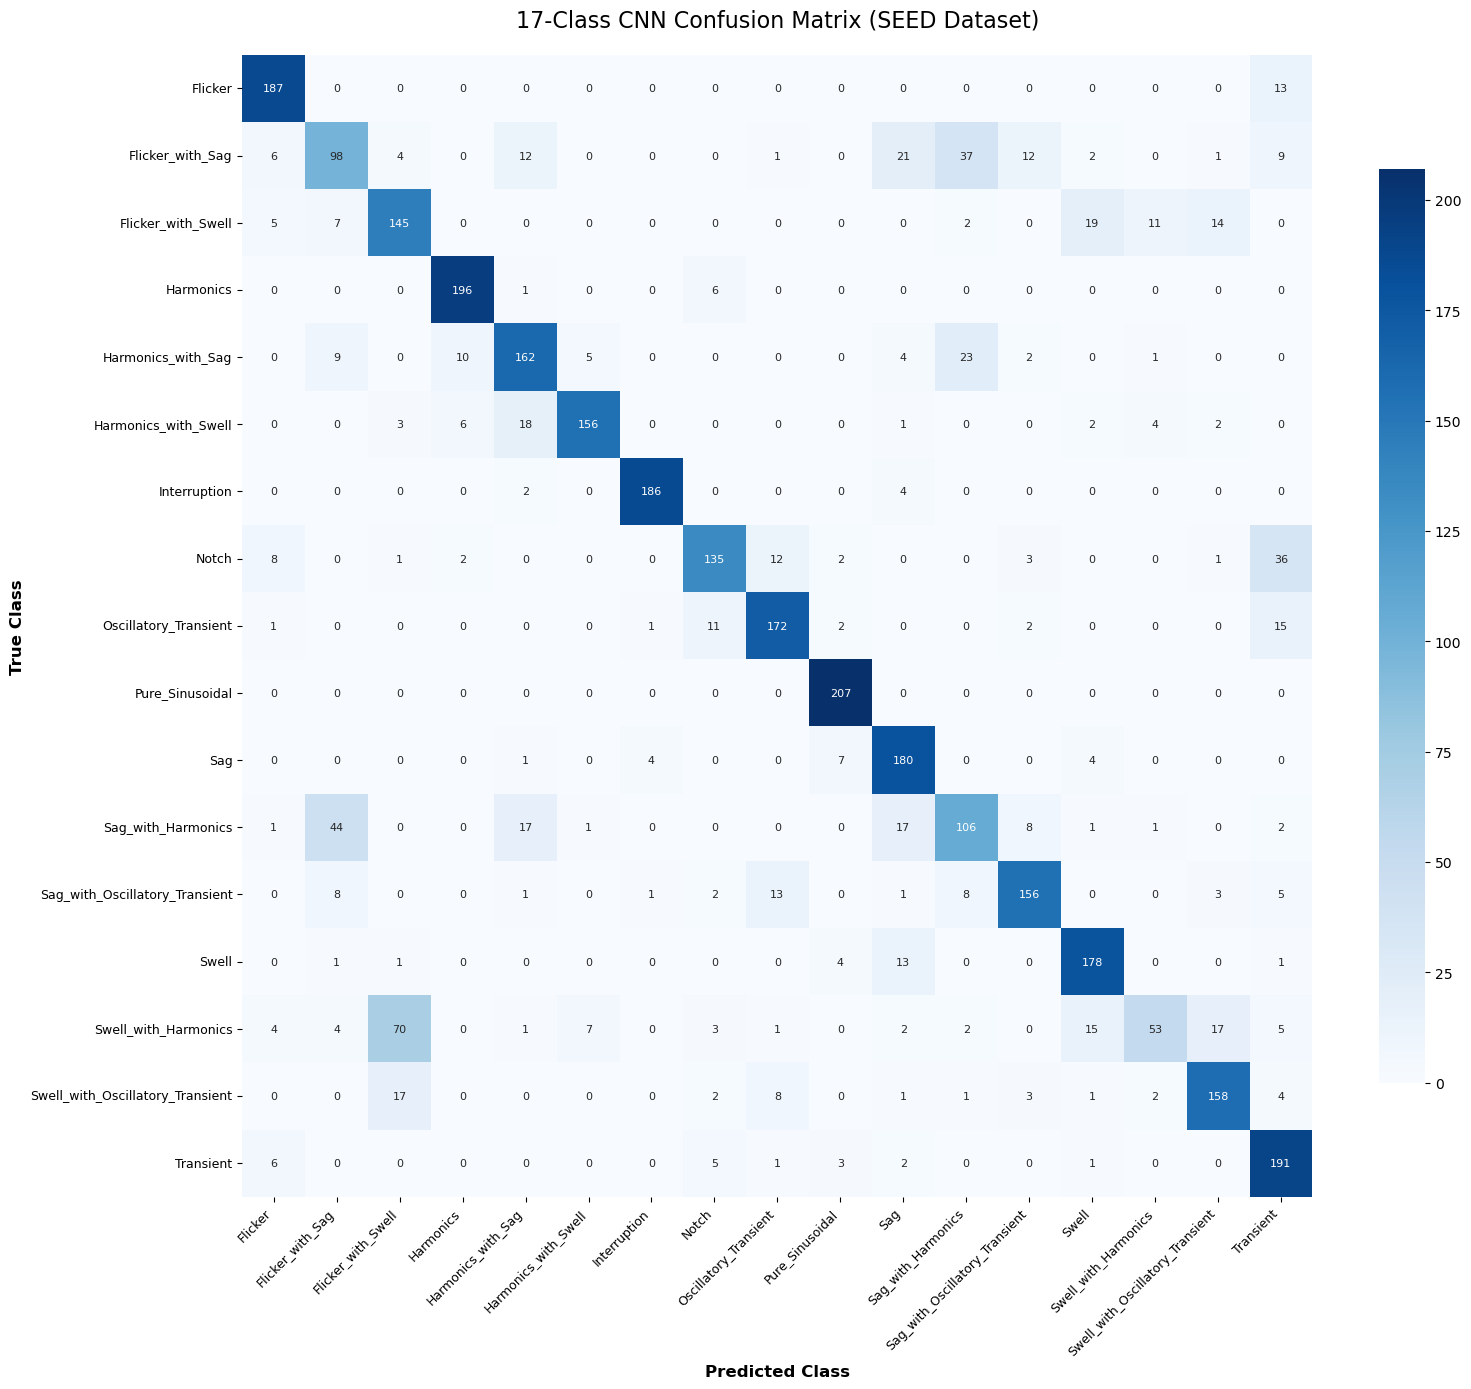

In [9]:
# 5. Visualizations for the 17-Class CNN
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Extract metrics from the training history
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs_range = range(len(acc))

# --- Plot A: Accuracy & Loss Curves ---
plt.figure(figsize=(14, 5))

# Accuracy Subplot
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy', linewidth=2)
plt.plot(epochs_range, val_acc, label='Validation Accuracy', linewidth=2)
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy', fontsize=14)
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.grid(True, linestyle='--', alpha=0.7)

# Loss Subplot
plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss', linewidth=2)
plt.plot(epochs_range, val_loss, label='Validation Loss', linewidth=2)
plt.legend(loc='upper right')
plt.title('Training and Validation Loss', fontsize=14)
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.savefig('seed_learning_curves.png', dpi=300) # Save high-res for the report
plt.show()

# --- Plot B: 17-Class Confusion Matrix ---
# Generate the matrix
conf_matrix = confusion_matrix(y_true, y_pred)

# Set up a very large figure size to accommodate the 17x17 grid
plt.figure(figsize=(16, 14))

# Use a heatmap with smaller annotation text to fit the numbers
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', 
            xticklabels=class_names, yticklabels=class_names,
            annot_kws={"size": 8}, cbar_kws={'shrink': 0.8})

plt.title('17-Class CNN Confusion Matrix (SEED Dataset)', fontsize=16, pad=20)
plt.ylabel('True Class', fontsize=12, fontweight='bold')
plt.xlabel('Predicted Class', fontsize=12, fontweight='bold')

# Rotate the x-axis labels so the long names are readable
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.yticks(fontsize=9)

plt.tight_layout()
plt.savefig('seed_confusion_matrix.png', dpi=300, bbox_inches='tight') # Save high-res for the report
plt.show()

We obtain more reliable results compared with the synthetic data.
- Acceptable results obtained with a 25 epoches - training.
- The conffusion matrix helps us identify the exact mistake for each class.
- For 17 classes we can reach an accuracy of 78%

# Proposed Improvements for the next delivery

- Include more existing datasets.
- Make comparisson with other classifiers, including non DL approaches like SVM.
- Preprocessing improvements:
    1. SpecAugment (Time and Frequency Masking)

    2. CLAHE (Contrast Limited Adaptive Histogram Equalization)

    3. Grayscale Conversion vs. Colormaps



 ### Preprocessing improvements:
 
    1. SpecAugment (Time and Frequency Masking)

    2. CLAHE (Contrast Limited Adaptive Histogram Equalization)

    3. Grayscale Conversion vs. Colormaps

In [4]:
import os
import numpy as np
import pandas as pd
import pywt
import cv2
import matplotlib.pyplot as plt

def process_seed_dataset(csv_folder="SEED_CSV_Data", output_dir="seed_spectrograms_cv"):
    """
    Reads the 17 SEED dataset CSV files, applies CWT, enhances with CLAHE, 
    and saves as 128x128 grayscale images.
    """
    classes = [
        "Pure_Sinusoidal", "Sag", "Swell", "Interruption", "Transient", 
        "Oscillatory_Transient", "Harmonics", "Harmonics_with_Sag", 
        "Harmonics_with_Swell", "Flicker", "Flicker_with_Sag", 
        "Flicker_with_Swell", "Sag_with_Oscillatory_Transient", 
        "Swell_with_Oscillatory_Transient", "Sag_with_Harmonics", 
        "Swell_with_Harmonics", "Notch"
    ]
    
    # Create the directory structure
    for cls_name in classes:
        os.makedirs(os.path.join(output_dir, cls_name), exist_ok=True)
        
    print(f"Generating SEED CWT Spectrograms in: {os.path.abspath(output_dir)}")
    
    # CWT and CLAHE Parameters
    scales = np.arange(1, 128)
    wavelet = 'cmor'
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    target_size = (128, 128) # Force standard square size for the CNN
    
    for class_idx, class_name in enumerate(classes):
        csv_path = os.path.join(csv_folder, f"{class_name}.csv")
        
        if not os.path.exists(csv_path):
            print(f"Warning: Could not find {csv_path}. Skipping.")
            continue
            
        print(f"Processing Class {class_idx + 1}/17: {class_name}...")
        
        # Read the CSV (Assuming 1000 rows x 100 columns, no headers)
        df = pd.read_csv(csv_path, header=None)
        signals = df.values
        
        for i in range(len(signals)):
            signal = signals[i]
            
            # 1. Apply Continuous Wavelet Transform
            coeffs, _ = pywt.cwt(signal, scales, wavelet)
            power = np.abs(coeffs)**2
            
            # 2. Normalize to 8-bit Grayscale
            power_scaled = cv2.normalize(power, None, 0, 255, cv2.NORM_MINMAX, dtype=cv2.CV_8U)
            
            # 3. Apply CLAHE for contrast enhancement
            power_clahe = clahe.apply(power_scaled)
            
            # 4. Resize from (127, 100) to (128, 128) to standardize CNN input
            power_resized = cv2.resize(power_clahe, target_size, interpolation=cv2.INTER_CUBIC)
            
            # 5. Save the image
            filename = os.path.join(output_dir, class_name, f"{class_name}_{i:04d}.png")
            cv2.imwrite(filename, power_resized)

    print("\nSEED Dataset image generation completely successfully!")

# Execute the ingestion
if __name__ == "__main__":
    process_seed_dataset()

Generating SEED CWT Spectrograms in: /mnt/c/py/ArtificialVision/seed_spectrograms_cv
Processing Class 1/17: Pure_Sinusoidal...


/home/mauro_wsl/miniconda3/envs/vision_gpu/lib/python3.10/site-packages/pywt/_cwt.py:117: FutureWarning: Wavelets from the family cmor, without parameters specified in the name are deprecated. The name should follow the format cmorB-C, where B and C are floats representing the bandwidth frequency and center frequency, respectively (example, for backward compatibility: cmor = cmor1.0-0.5).
  wavelet = DiscreteContinuousWavelet(wavelet)


Processing Class 2/17: Sag...


/home/mauro_wsl/miniconda3/envs/vision_gpu/lib/python3.10/site-packages/pywt/_cwt.py:117: FutureWarning: Wavelets from the family cmor, without parameters specified in the name are deprecated. The name should follow the format cmorB-C, where B and C are floats representing the bandwidth frequency and center frequency, respectively (example, for backward compatibility: cmor = cmor1.0-0.5).
  wavelet = DiscreteContinuousWavelet(wavelet)


Processing Class 3/17: Swell...


...

Processing Class 16/17: Swell_with_Harmonics...


/home/mauro_wsl/miniconda3/envs/vision_gpu/lib/python3.10/site-packages/pywt/_cwt.py:117: FutureWarning: Wavelets from the family cmor, without parameters specified in the name are deprecated. The name should follow the format cmorB-C, where B and C are floats representing the bandwidth frequency and center frequency, respectively (example, for backward compatibility: cmor = cmor1.0-0.5).
  wavelet = DiscreteContinuousWavelet(wavelet)


Processing Class 17/17: Notch...


/home/mauro_wsl/miniconda3/envs/vision_gpu/lib/python3.10/site-packages/pywt/_cwt.py:117: FutureWarning: Wavelets from the family cmor, without parameters specified in the name are deprecated. The name should follow the format cmorB-C, where B and C are floats representing the bandwidth frequency and center frequency, respectively (example, for backward compatibility: cmor = cmor1.0-0.5).
  wavelet = DiscreteContinuousWavelet(wavelet)



SEED Dataset image generation completely successfully!


### Training the 17-Class CNN with the advanced preprocessing


In [9]:
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

def apply_spec_augment(image, label):
    """SpecAugment to prevent overfitting on the 17 classes."""
    F_max = 10  # Reduced mask size since signals are only 1 cycle long
    T_max = 10  
    
    # Frequency Masking
    f = tf.random.uniform([], minval=0, maxval=F_max, dtype=tf.int32)
    f0 = tf.random.uniform([], minval=0, maxval=128 - f, dtype=tf.int32)
    mask_f = tf.concat([
        tf.ones([f0, 128, 1], dtype=tf.float32),
        tf.zeros([f, 128, 1], dtype=tf.float32),
        tf.ones([128 - f0 - f, 128, 1], dtype=tf.float32)
    ], axis=0)
    image = image * mask_f
    
    # Time Masking
    t = tf.random.uniform([], minval=0, maxval=T_max, dtype=tf.int32)
    t0 = tf.random.uniform([], minval=0, maxval=128 - t, dtype=tf.int32)
    mask_t = tf.concat([
        tf.ones([128, t0, 1], dtype=tf.float32),
        tf.zeros([128, t, 1], dtype=tf.float32),
        tf.ones([128, 128 - t0 - t, 1], dtype=tf.float32)
    ], axis=1)
    image = image * mask_t
    return image, label

# 1. Dataset Configuration
batch_size = 32
img_height = 128
img_width = 128
data_dir = "seed_spectrograms_cv" # Pointing to the new SEED images

print("Loading SEED datasets...")
train_ds = tf.keras.utils.image_dataset_from_directory(
  data_dir,
  validation_split=0.2,
  subset="training",
  seed=123,
  color_mode='grayscale',
  image_size=(img_height, img_width),
  batch_size=batch_size)

val_ds = tf.keras.utils.image_dataset_from_directory(
  data_dir,
  validation_split=0.2,
  subset="validation",
  seed=123,
  color_mode='grayscale',
  image_size=(img_height, img_width),
  batch_size=batch_size) # Remember, no shuffle=False here!

class_names = train_ds.class_names

AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.map(apply_spec_augment, num_parallel_calls=AUTOTUNE)
train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)

# 2. 17-Class CNN Architecture
model = models.Sequential([
  layers.Rescaling(1./255, input_shape=(img_height, img_width, 1)),
  
  layers.Conv2D(32, 3, padding='same', activation='relu'),
  layers.MaxPooling2D(),
  
  layers.Conv2D(64, 3, padding='same', activation='relu'),
  layers.MaxPooling2D(),
  
  layers.Conv2D(128, 3, padding='same', activation='relu'),
  layers.MaxPooling2D(),
  
  layers.Flatten(),
  layers.Dense(256, activation='relu'), # Increased dense neurons for 17 classes
  layers.Dropout(0.4), # Stronger dropout to handle dataset complexity
  layers.Dense(17) # Output exactly 17 nodes for the SEED classes
])

model.compile(optimizer='adam',
              loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
              metrics=['accuracy'])

# 3. Train the Network
epochs = 40 # Increased slightly due to 17-class complexity
history = model.fit(train_ds, validation_data=val_ds, epochs=epochs)

# 4. Evaluation (Confusion Matrix logic remains identical, just larger)
y_true = np.concatenate([y for x, y in val_ds], axis=0)
predictions = model.predict(val_ds)
y_pred = np.argmax(predictions, axis=1)

print("\n--- SEED Dataset CNN Results ---")
print(classification_report(y_true, y_pred, target_names=class_names))

Loading SEED datasets...
Found 17000 files belonging to 17 classes.
Using 13600 files for training.
Found 17000 files belonging to 17 classes.
Using 3400 files for validation.
Epoch 1/40


2026-04-24 16:30:29.492620: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'Placeholder/_4' with dtype int32 and shape [13600]
	 [[{{node Placeholder/_4}}]]
2026-04-24 16:30:29.492959: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'Placeholder/_4' with dtype int32 and shape [13600]
	 [[{{node Placeholder/_4}}]]


423/425 [============================>.] - ETA: 0s - loss: 2.2839 - accuracy: 0.2325

2026-04-24 16:30:45.191745: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'Placeholder/_0' with dtype string and shape [3400]
	 [[{{node Placeholder/_0}}]]
2026-04-24 16:30:45.192185: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'Placeholder/_4' with dtype int32 and shape [3400]
	 [[{{node Placeholder/_4}}]]


425/425 [==============================] - 17s 26ms/step - loss: 2.2816 - accuracy: 0.2334 - val_loss: 1.7591 - val_accuracy: 0.3894
Epoch 2/40
425/425 [==============================] - 10s 23ms/step - loss: 1.6973 - accuracy: 0.4010 - val_loss: 1.3532 - val_accuracy: 0.5468
Epoch 3/40
425/425 [==============================] - 10s 23ms/step - loss: 1.3870 - accuracy: 0.5155 - val_loss: 1.1046 - val_accuracy: 0.6294
Epoch 4/40
425/425 [==============================] - 10s 24ms/step - loss: 1.2052 - accuracy: 0.5802 - val_loss: 1.0372 - val_accuracy: 0.6229
Epoch 5/40
425/425 [==============================] - 10s 23ms/step - loss: 1.0687 - accuracy: 0.6250 - val_loss: 0.8806 - val_accuracy: 0.7179
Epoch 6/40
425/425 [==============================] - 10s 23ms/step - loss: 0.9942 - accuracy: 0.6523 - val_loss: 0.7910 - val_accuracy: 0.7444
Epoch 7/40
425/425 [==============================] - 10s 23ms/step - loss: 0.9102 - accuracy: 0.6794 - val_loss: 0.7887 - val_accuracy: 0.7326
Epo

### Visualization

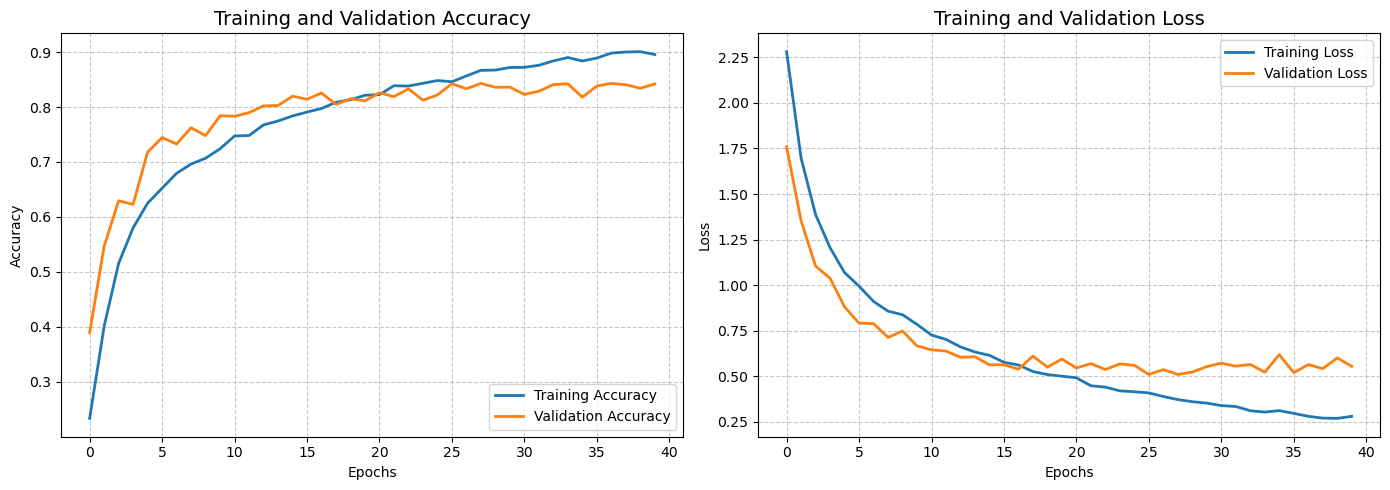

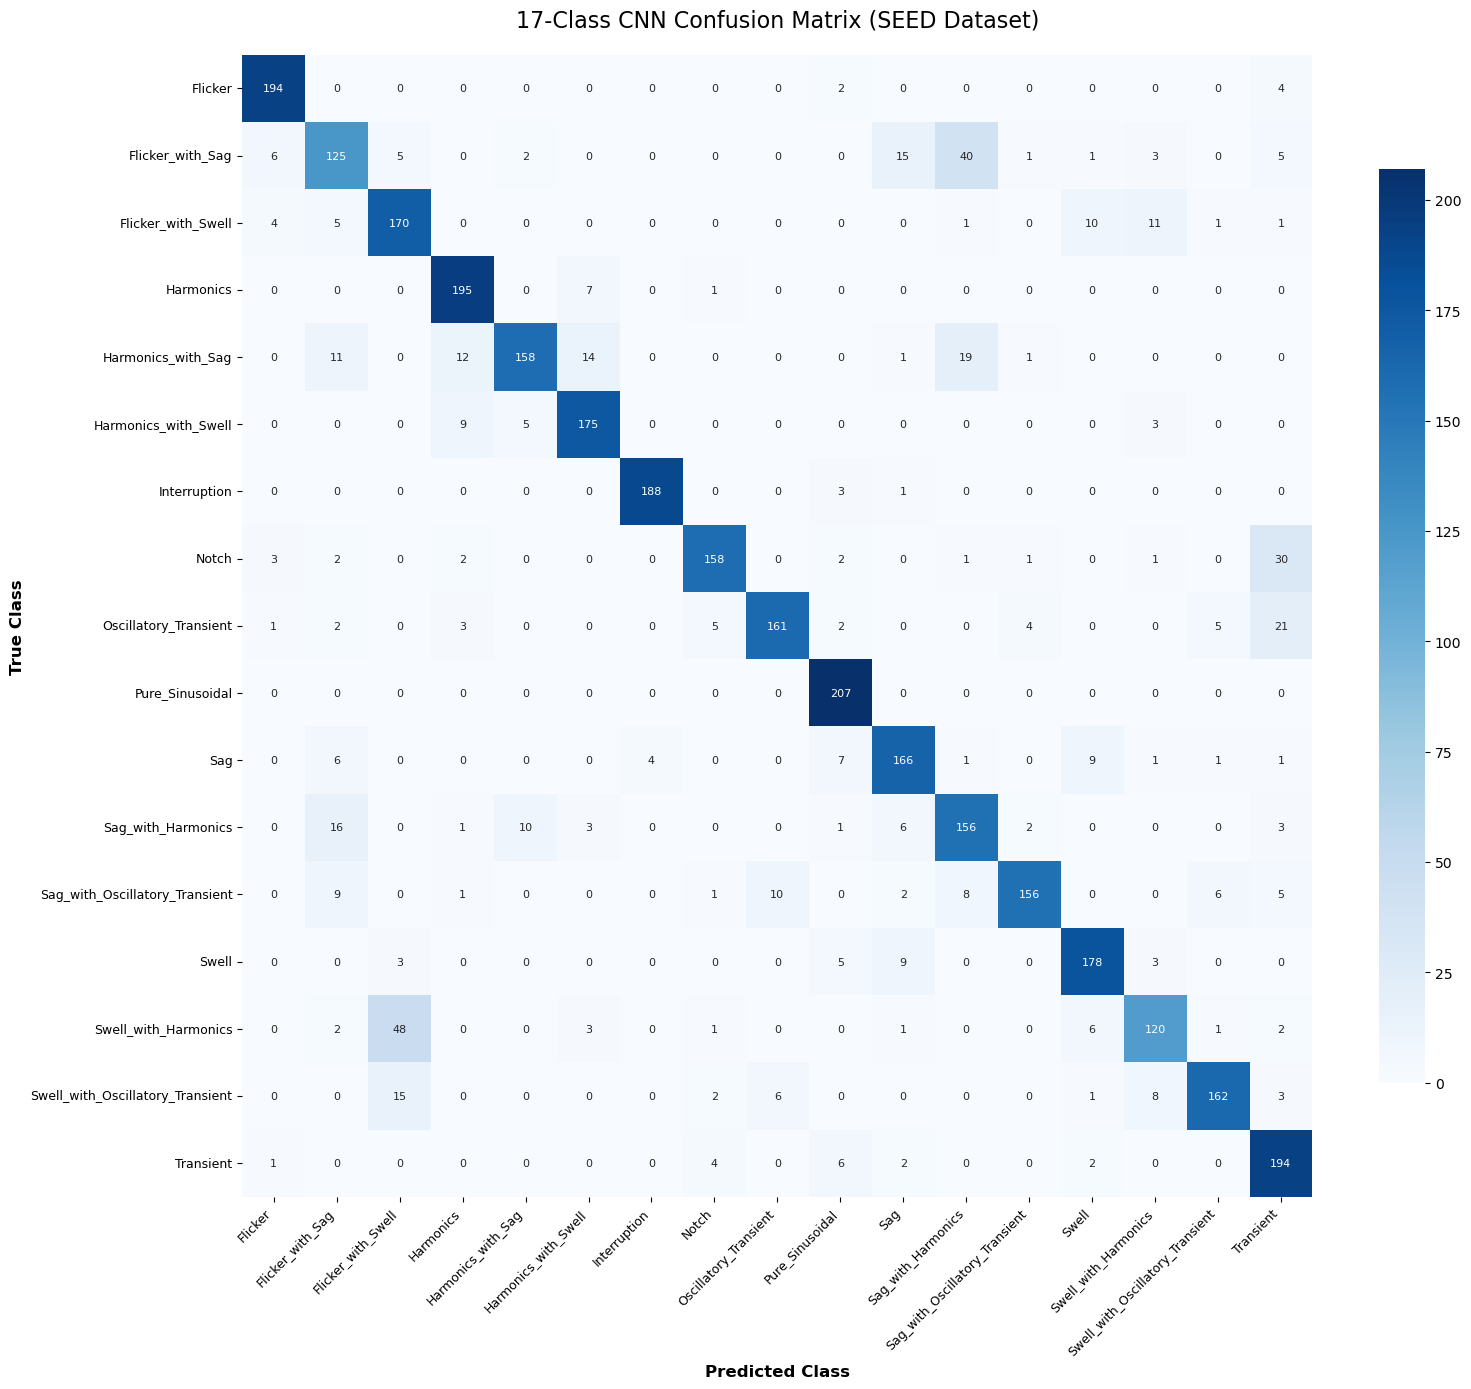

In [10]:
# 5. Visualizations for the 17-Class CNN
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Extract metrics from the training history
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs_range = range(len(acc))

# --- Plot A: Accuracy & Loss Curves ---
plt.figure(figsize=(14, 5))

# Accuracy Subplot
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy', linewidth=2)
plt.plot(epochs_range, val_acc, label='Validation Accuracy', linewidth=2)
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy', fontsize=14)
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.grid(True, linestyle='--', alpha=0.7)

# Loss Subplot
plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss', linewidth=2)
plt.plot(epochs_range, val_loss, label='Validation Loss', linewidth=2)
plt.legend(loc='upper right')
plt.title('Training and Validation Loss', fontsize=14)
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.savefig('seed_learning_curves.png', dpi=300) # Save high-res for the report
plt.show()

# --- Plot B: 17-Class Confusion Matrix ---
# Generate the matrix
conf_matrix = confusion_matrix(y_true, y_pred)

# Set up a very large figure size to accommodate the 17x17 grid
plt.figure(figsize=(16, 14))

# Use a heatmap with smaller annotation text to fit the numbers
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', 
            xticklabels=class_names, yticklabels=class_names,
            annot_kws={"size": 8}, cbar_kws={'shrink': 0.8})

plt.title('17-Class CNN Confusion Matrix (SEED Dataset)', fontsize=16, pad=20)
plt.ylabel('True Class', fontsize=12, fontweight='bold')
plt.xlabel('Predicted Class', fontsize=12, fontweight='bold')

# Rotate the x-axis labels so the long names are readable
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.yticks(fontsize=9)

plt.tight_layout()
plt.savefig('seed_confusion_matrix.png', dpi=300, bbox_inches='tight') # Save high-res for the report
plt.show()

### CRNN (CNN + LSTM) Implementation

The CRNN (Convolutional Recurrent Neural Network)

- **The spectrograms have a specific physical meaning:** the Y-axis is frequency, and the X-axis is strictly time. A standard CNN treats the image as a static spatial grid, somewhat ignoring the sequential flow of time.

- **The Architecture:** A CRNN uses a few CNN layers to extract the frequency textures (like harmonic bands), but then reshapes that output and feeds it into an LSTM (Long Short-Term Memory) or GRU layer.

- **Why it fits the problem:** The LSTM steps through the CNN feature maps column-by-column (time-step by time-step). This is incredibly powerful for classifying things like Sag_with_Oscillatory_Transient, because the LSTM learns the temporal sequence of the fault (e.g., "First the voltage drops, then there is high-frequency ringing, then it recovers").

In [3]:
import tensorflow as tf
from tensorflow.keras import layers, models
import numpy as np
from sklearn.metrics import classification_report

# 1. Dataset Configuration
batch_size = 32
img_height = 128
img_width = 128
data_dir = "seed_spectrograms_cv" # Using the advanced 1-channel dataset

print("Loading SEED datasets for CRNN...")
train_ds = tf.keras.utils.image_dataset_from_directory(
  data_dir,
  validation_split=0.2,
  subset="training",
  seed=123,
  color_mode='grayscale', # 1-channel
  image_size=(img_height, img_width),
  batch_size=batch_size)

val_ds = tf.keras.utils.image_dataset_from_directory(
  data_dir,
  validation_split=0.2,
  subset="validation",
  seed=123,
  color_mode='grayscale',
  image_size=(img_height, img_width),
  batch_size=batch_size)

class_names = train_ds.class_names

# Optimization
AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)

# 2. Build the CRNN Architecture
def build_crnn_model(input_shape=(128, 128, 1), num_classes=17):
    model = models.Sequential()
    
    # Preprocessing
    model.add(layers.Rescaling(1./255, input_shape=input_shape))
    
    # --- CNN Feature Extractor ---
    # We use aggressive MaxPooling on the frequency axis (y) but keep the time axis (x) wider
    model.add(layers.Conv2D(32, (3, 3), padding='same', activation='relu'))
    model.add(layers.MaxPooling2D(pool_size=(2, 2))) # Output: (64, 64, 32)
    
    model.add(layers.Conv2D(64, (3, 3), padding='same', activation='relu'))
    model.add(layers.MaxPooling2D(pool_size=(2, 2))) # Output: (32, 32, 64)
    
    model.add(layers.Conv2D(128, (3, 3), padding='same', activation='relu'))
    model.add(layers.MaxPooling2D(pool_size=(2, 2))) # Output: (16, 16, 128)
    
    # --- The Transpose & Reshape Bridge ---
    # Current shape: (Batch, Height/Freq=16, Width/Time=16, Channels=128)
    # We must swap Height and Width so time is the sequence dimension for the LSTM.
    # Permute(dims=(2, 1, 3)) changes it to: (Batch, Time=16, Freq=16, Channels=128)
    model.add(layers.Permute((2, 1, 3)))
    
    # Flatten the Freq and Channels into a single feature vector per time-step
    # Shape becomes: (Batch, TimeSteps=16, Features=16*128)
    model.add(layers.Reshape((16, 16 * 128)))
    
    # --- Sequence Learning (RNN) ---
    # The LSTM steps through the 16 time-slices, remembering the temporal sequence
    model.add(layers.LSTM(128, return_sequences=False))
    
    # Regularization & Classification
    model.add(layers.Dropout(0.4))
    model.add(layers.Dense(64, activation='relu'))
    model.add(layers.Dense(num_classes))
    
    return model

crnn_model = build_crnn_model()

crnn_model.compile(optimizer='adam',
              loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
              metrics=['accuracy'])

crnn_model.summary()

# 3. Train the Network
epochs = 40
print("\nStarting CRNN Training...")
history_crnn = crnn_model.fit(train_ds, validation_data=val_ds, epochs=epochs)

# 4. Evaluation
print("\nEvaluating CRNN Model...")
y_true = np.concatenate([y for x, y in val_ds], axis=0)
predictions = crnn_model.predict(val_ds)
y_pred = np.argmax(predictions, axis=1)

print("\n--- CRNN (CNN+LSTM) Results ---")
print(classification_report(y_true, y_pred, target_names=class_names))

Loading SEED datasets for CRNN...
Found 17000 files belonging to 17 classes.
Using 13600 files for training.


2026-05-08 01:16:29.383302: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:982] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2026-05-08 01:16:29.383418: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:982] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2026-05-08 01:16:29.383438: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:982] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2026-05-08 01:16:29.540052: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:982] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2026-05-08 01:16:29.540143: I tensorflow/compile

Found 17000 files belonging to 17 classes.
Using 3400 files for validation.
Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 rescaling (Rescaling)       (None, 128, 128, 1)       0         
                                                                 
 conv2d (Conv2D)             (None, 128, 128, 32)      320       
                                                                 
 max_pooling2d (MaxPooling2D  (None, 64, 64, 32)       0         
 )                                                               
                                                                 
 conv2d_1 (Conv2D)           (None, 64, 64, 64)        18496     
                                                                 
 max_pooling2d_1 (MaxPooling  (None, 32, 32, 64)       0         
 2D)                                                             
                                              

2026-05-08 01:16:37.429502: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'gradients/split_2_grad/concat/split_2/split_dim' with dtype int32
	 [[{{node gradients/split_2_grad/concat/split_2/split_dim}}]]
2026-05-08 01:16:37.431126: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'gradients/split_grad/concat/split/split_dim' with dtype int32
	 [[{{node gradients/split_grad/concat/split/split_dim}}]]
2026-05-08 01:16:37.432001: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You mus

423/425 [============================>.] - ETA: 0s - loss: 2.4335 - accuracy: 0.1837

2026-05-08 01:16:55.987518: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'Placeholder/_0' with dtype string and shape [3400]
	 [[{{node Placeholder/_0}}]]
2026-05-08 01:16:55.987786: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'Placeholder/_0' with dtype string and shape [3400]
	 [[{{node Placeholder/_0}}]]
2026-05-08 01:16:56.110947: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'gradients/split_2_grad/concat/split_2/split_dim' 

425/425 [==============================] - 20s 26ms/step - loss: 2.4323 - accuracy: 0.1840 - val_loss: 2.1439 - val_accuracy: 0.2721
Epoch 2/40
425/425 [==============================] - 10s 24ms/step - loss: 2.0940 - accuracy: 0.2739 - val_loss: 1.9186 - val_accuracy: 0.2965
Epoch 3/40
425/425 [==============================] - 10s 24ms/step - loss: 1.8643 - accuracy: 0.3260 - val_loss: 1.6852 - val_accuracy: 0.3668
Epoch 4/40
425/425 [==============================] - 10s 24ms/step - loss: 1.6768 - accuracy: 0.3839 - val_loss: 1.6769 - val_accuracy: 0.3829
Epoch 5/40
425/425 [==============================] - 10s 24ms/step - loss: 1.4754 - accuracy: 0.4573 - val_loss: 1.2071 - val_accuracy: 0.5491
Epoch 6/40
425/425 [==============================] - 10s 24ms/step - loss: 1.1713 - accuracy: 0.5765 - val_loss: 0.9881 - val_accuracy: 0.6556
Epoch 7/40
425/425 [==============================] - 10s 24ms/step - loss: 0.9652 - accuracy: 0.6574 - val_loss: 0.8398 - val_accuracy: 0.7118
Epo

2026-05-08 01:23:34.284223: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'gradients/split_2_grad/concat/split_2/split_dim' with dtype int32
	 [[{{node gradients/split_2_grad/concat/split_2/split_dim}}]]
2026-05-08 01:23:34.285632: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'gradients/split_grad/concat/split/split_dim' with dtype int32
	 [[{{node gradients/split_grad/concat/split/split_dim}}]]
2026-05-08 01:23:34.286604: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You mus

107/107 [==============================] - 1s 8ms/step

--- CRNN (CNN+LSTM) Results ---
                                  precision    recall  f1-score   support

                         Flicker       0.93      1.00      0.96       200
                Flicker_with_Sag       0.91      0.83      0.87       203
              Flicker_with_Swell       0.88      0.90      0.89       203
                       Harmonics       0.96      0.97      0.96       203
              Harmonics_with_Sag       0.81      0.88      0.84       216
            Harmonics_with_Swell       0.92      0.86      0.89       192
                    Interruption       0.96      1.00      0.98       192
                           Notch       1.00      0.89      0.94       200
           Oscillatory_Transient       0.87      0.91      0.89       204
                 Pure_Sinusoidal       0.96      1.00      0.98       207
                             Sag       0.95      0.90      0.93       196
              Sag_with_

### Visualization

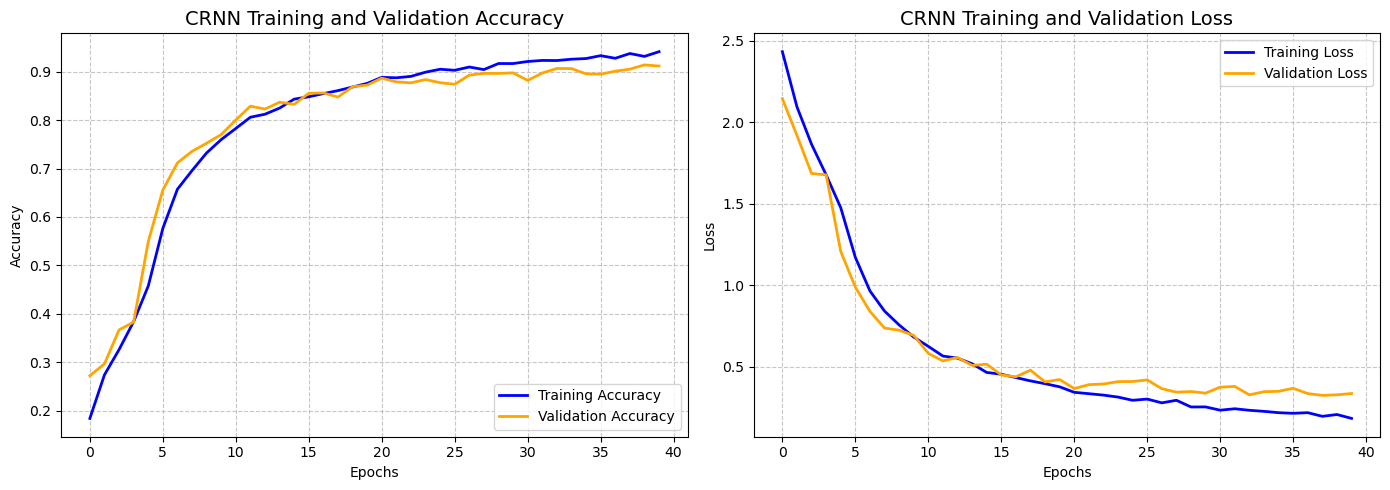

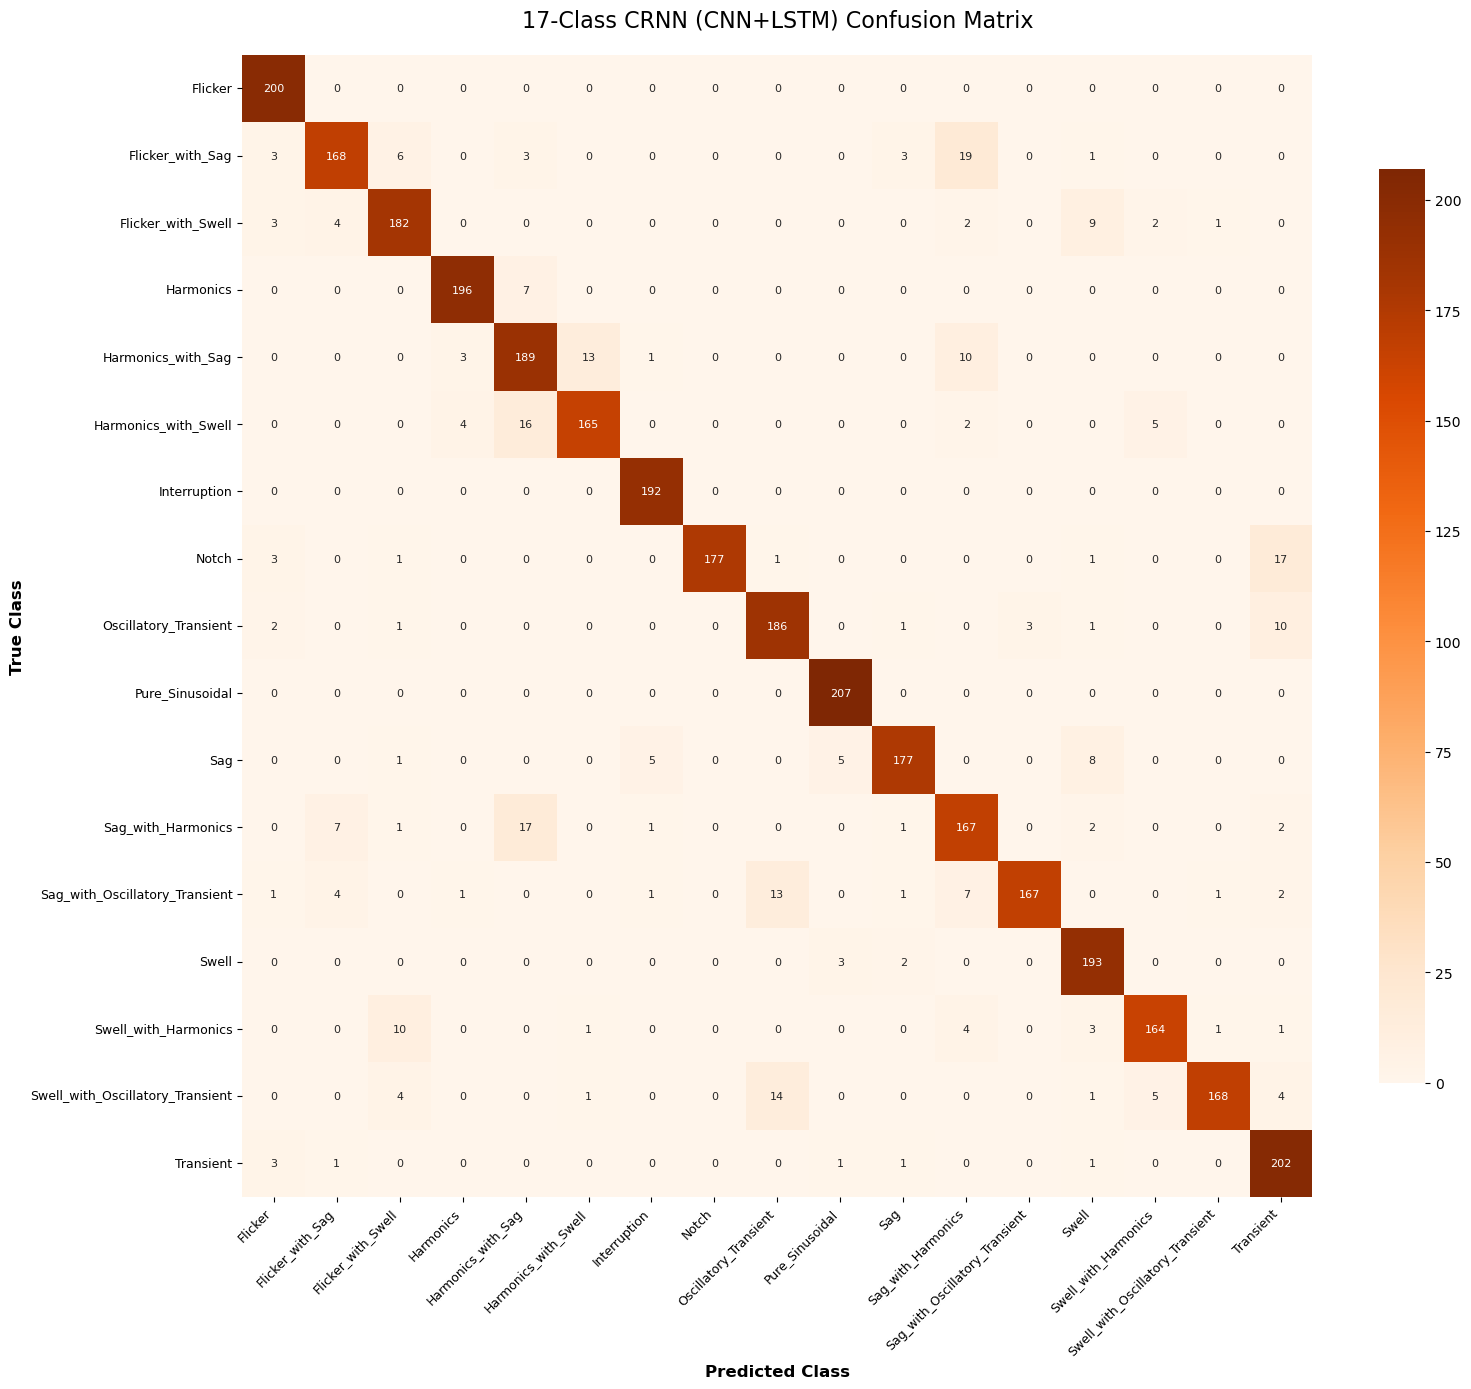

In [4]:
# 5. Visualizations for the CRNN (CNN + LSTM) Model
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Extract metrics from the CRNN training history
acc = history_crnn.history['accuracy']
val_acc = history_crnn.history['val_accuracy']
loss = history_crnn.history['loss']
val_loss = history_crnn.history['val_loss']
epochs_range = range(len(acc))

# --- Plot A: Accuracy & Loss Curves ---
plt.figure(figsize=(14, 5))

# Accuracy Subplot
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy', linewidth=2, color='blue')
plt.plot(epochs_range, val_acc, label='Validation Accuracy', linewidth=2, color='orange')
plt.legend(loc='lower right')
plt.title('CRNN Training and Validation Accuracy', fontsize=14)
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.grid(True, linestyle='--', alpha=0.7)

# Loss Subplot
plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss', linewidth=2, color='blue')
plt.plot(epochs_range, val_loss, label='Validation Loss', linewidth=2, color='orange')
plt.legend(loc='upper right')
plt.title('CRNN Training and Validation Loss', fontsize=14)
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.savefig('crnn_learning_curves.png', dpi=300) 
plt.show()

# --- Plot B: 17-Class CRNN Confusion Matrix ---
# Generate the matrix using the y_true and y_pred from the CRNN evaluation
conf_matrix = confusion_matrix(y_true, y_pred)

# Set up a large figure size for the 17x17 grid
plt.figure(figsize=(16, 14))

# Heatmap with adjusted annotation size
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Oranges', # Switched to Oranges to visually distinguish from CNN plots
            xticklabels=class_names, yticklabels=class_names,
            annot_kws={"size": 8}, cbar_kws={'shrink': 0.8})

plt.title('17-Class CRNN (CNN+LSTM) Confusion Matrix', fontsize=16, pad=20)
plt.ylabel('True Class', fontsize=12, fontweight='bold')
plt.xlabel('Predicted Class', fontsize=12, fontweight='bold')

# Rotate the x-axis labels for readability
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.yticks(fontsize=9)

plt.tight_layout()
plt.savefig('crnn_confusion_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

### The "3-Channel" Catch for Transfer Learning
Because MobileNetV2 was pre-trained on ImageNet (a massive dataset of color photographs), its input layer strictly requires 3-channel RGB images. Even though our SEED spectrograms are mathematically 1-channel Grayscale, we simply tell Keras to load them with color_mode='rgb'. Keras will automatically duplicate the grayscale matrix across three channels to satisfy the architecture's requirements.

Loading SEED datasets for MobileNetV2...
Found 17000 files belonging to 17 classes.
Using 13600 files for training.
Found 17000 files belonging to 17 classes.
Using 3400 files for validation.
Model: "model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_2 (InputLayer)        [(None, 128, 128, 3)]     0         
                                                                 
 tf.math.truediv (TFOpLambda  (None, 128, 128, 3)      0         
 )                                                               
                                                                 
 tf.math.subtract (TFOpLambd  (None, 128, 128, 3)      0         
 a)                                                              
                                                                 
 mobilenetv2_1.00_128 (Funct  (None, 4, 4, 1280)       2257984   
 ional)                                                          
 

2026-05-08 01:24:40.622801: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'Placeholder/_4' with dtype int32 and shape [13600]
	 [[{{node Placeholder/_4}}]]
2026-05-08 01:24:40.623114: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'Placeholder/_4' with dtype int32 and shape [13600]
	 [[{{node Placeholder/_4}}]]


423/425 [============================>.] - ETA: 0s - loss: 1.9821 - accuracy: 0.3558

2026-05-08 01:24:56.418900: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'Placeholder/_4' with dtype int32 and shape [3400]
	 [[{{node Placeholder/_4}}]]
2026-05-08 01:24:56.419188: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'Placeholder/_4' with dtype int32 and shape [3400]
	 [[{{node Placeholder/_4}}]]


425/425 [==============================] - 19s 27ms/step - loss: 1.9800 - accuracy: 0.3565 - val_loss: 1.4434 - val_accuracy: 0.4915
Epoch 2/40
425/425 [==============================] - 11s 25ms/step - loss: 1.4558 - accuracy: 0.5024 - val_loss: 1.2558 - val_accuracy: 0.5659
Epoch 3/40
425/425 [==============================] - 11s 25ms/step - loss: 1.3262 - accuracy: 0.5412 - val_loss: 1.2070 - val_accuracy: 0.5718
Epoch 4/40
425/425 [==============================] - 11s 25ms/step - loss: 1.2538 - accuracy: 0.5631 - val_loss: 1.1441 - val_accuracy: 0.5900
Epoch 5/40
425/425 [==============================] - 11s 25ms/step - loss: 1.2176 - accuracy: 0.5712 - val_loss: 1.0834 - val_accuracy: 0.6203
Epoch 6/40
425/425 [==============================] - 11s 25ms/step - loss: 1.1823 - accuracy: 0.5816 - val_loss: 1.0807 - val_accuracy: 0.6318
Epoch 7/40
425/425 [==============================] - 11s 25ms/step - loss: 1.1609 - accuracy: 0.5901 - val_loss: 1.0829 - val_accuracy: 0.6053
Epo

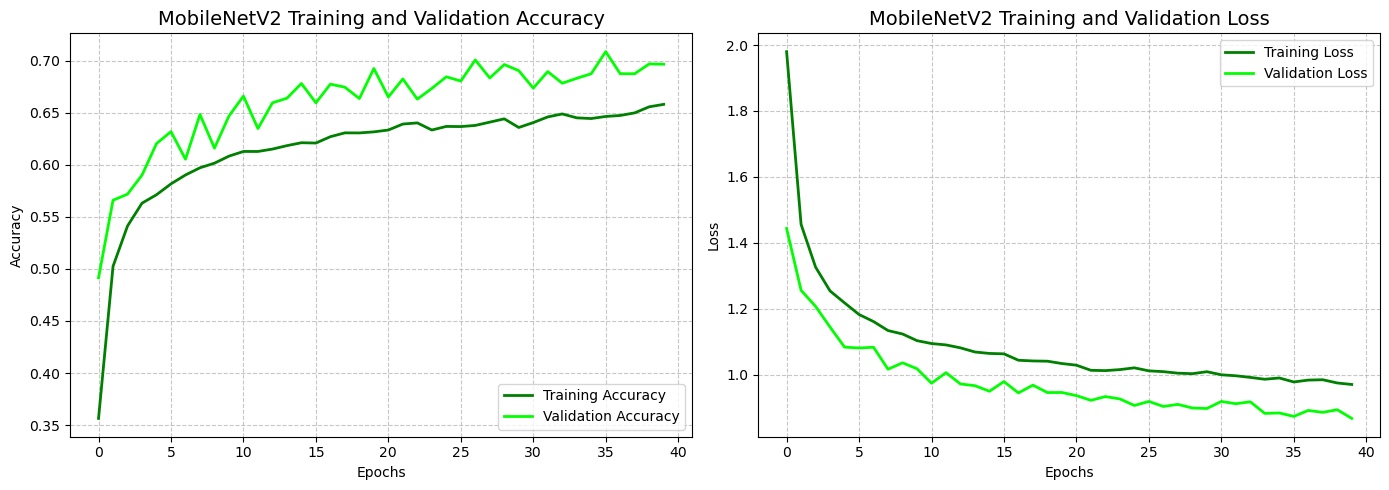

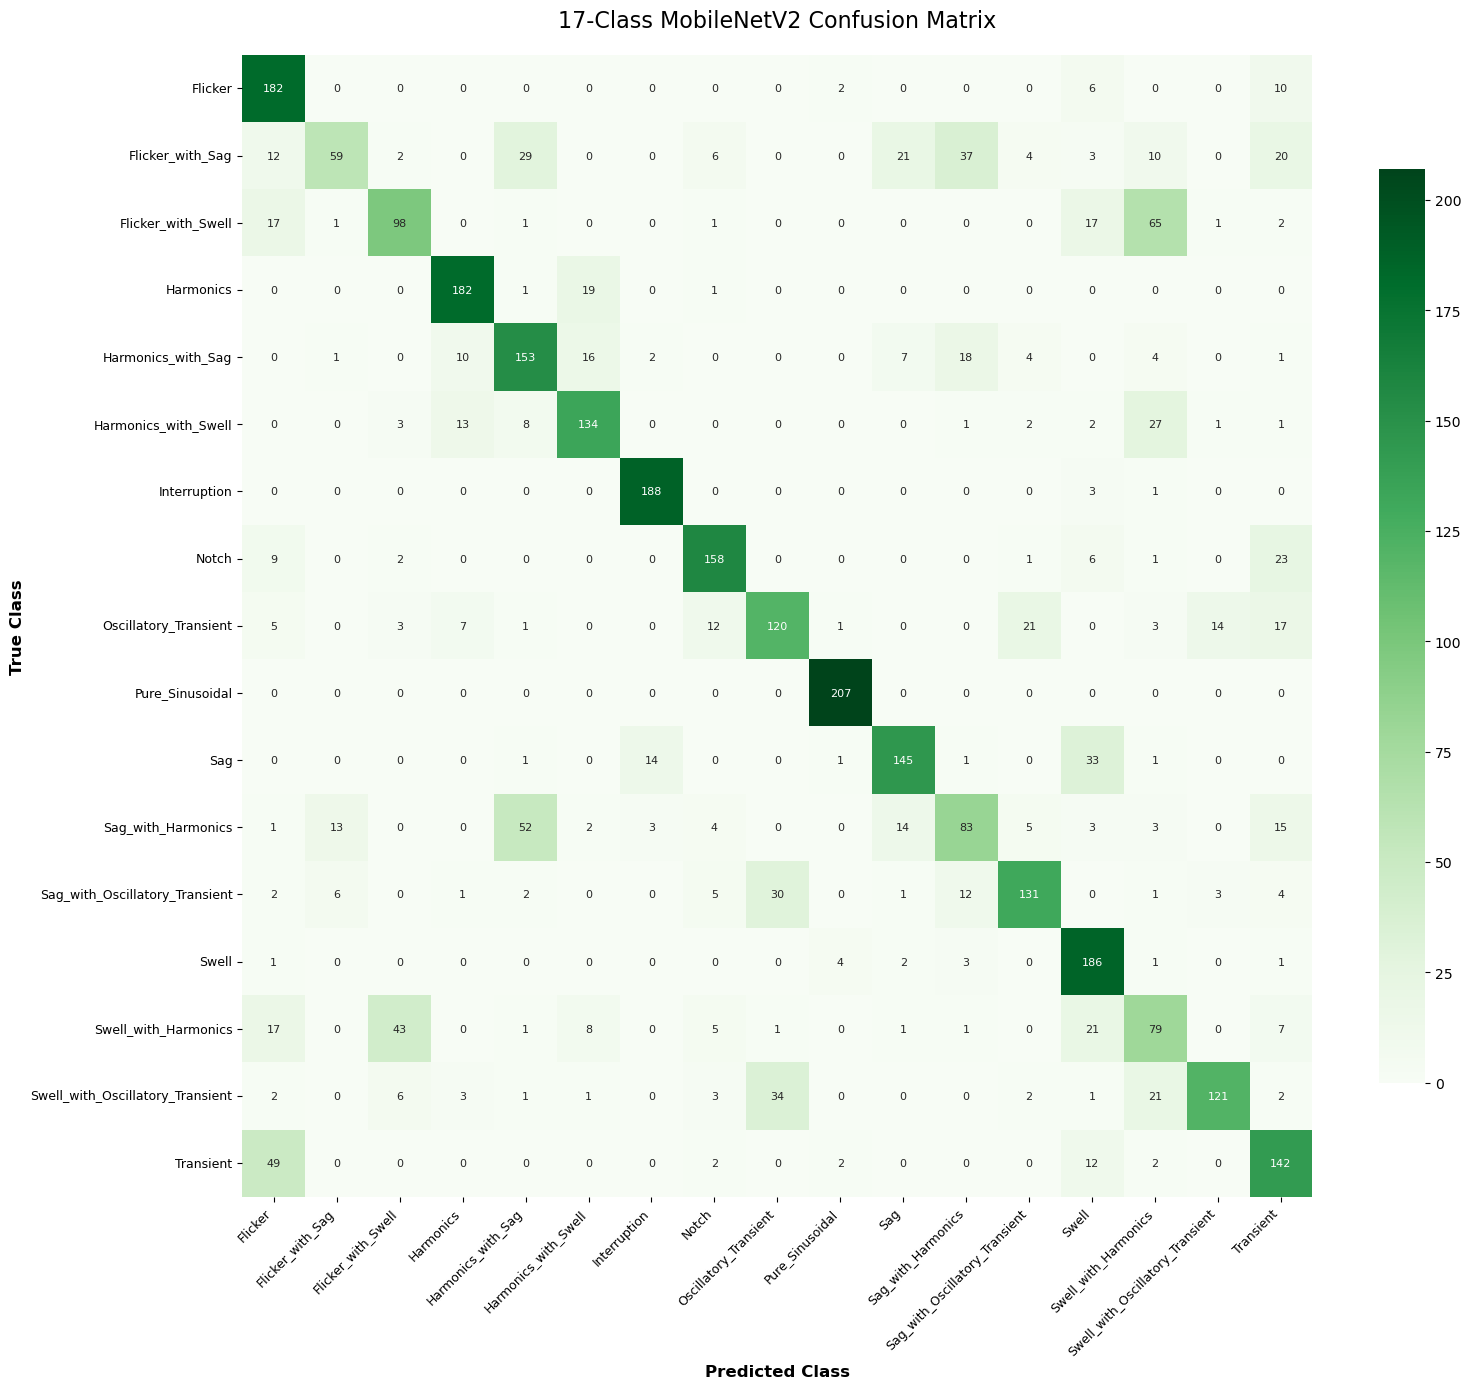

In [5]:
import tensorflow as tf
from tensorflow.keras import layers, models
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

# 1. Dataset Configuration (Notice color_mode='rgb')
batch_size = 32
img_height = 128
img_width = 128
data_dir = "seed_spectrograms_cv" 

print("Loading SEED datasets for MobileNetV2...")
train_ds = tf.keras.utils.image_dataset_from_directory(
  data_dir,
  validation_split=0.2,
  subset="training",
  seed=123,
  color_mode='rgb', # Required for ImageNet pretrained models
  image_size=(img_height, img_width),
  batch_size=batch_size)

val_ds = tf.keras.utils.image_dataset_from_directory(
  data_dir,
  validation_split=0.2,
  subset="validation",
  seed=123,
  color_mode='rgb', 
  image_size=(img_height, img_width),
  batch_size=batch_size)

class_names = train_ds.class_names

AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)

# 2. Build the MobileNetV2 Transfer Learning Model
# We load the base model WITHOUT the final classification layers (include_top=False)
base_model = tf.keras.applications.MobileNetV2(
    input_shape=(128, 128, 3),
    include_top=False,
    weights='imagenet' # Load the pre-trained knowledge
)

# Freeze the base model so we don't destroy the pre-trained weights during initial training
base_model.trainable = False 

# Construct the custom classification head
inputs = tf.keras.Input(shape=(128, 128, 3))

# MobileNetV2 requires pixels to be scaled between [-1, 1], NOT [0, 1]. 
# This built-in function handles the exact mathematical scaling automatically.
x = tf.keras.applications.mobilenet_v2.preprocess_input(inputs)

# Pass through the frozen base model
x = base_model(x, training=False)

# Convert the spatial features into a 1D vector
x = layers.GlobalAveragePooling2D()(x)

# Regularization
x = layers.Dropout(0.4)(x)

# Output layer for the 17 SEED classes
outputs = layers.Dense(17)(x)

mobilenet_model = tf.keras.Model(inputs, outputs)

mobilenet_model.compile(optimizer='adam',
              loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
              metrics=['accuracy'])

mobilenet_model.summary()

# 3. Train the Network
epochs = 40
print("\nStarting MobileNetV2 Training...")
history_mobile = mobilenet_model.fit(train_ds, validation_data=val_ds, epochs=epochs)

# 4. Evaluation
print("\nEvaluating MobileNetV2 Model...")
y_true = np.concatenate([y for x, y in val_ds], axis=0)
predictions = mobilenet_model.predict(val_ds)
y_pred = np.argmax(predictions, axis=1)

print("\n--- MobileNetV2 Transfer Learning Results ---")
print(classification_report(y_true, y_pred, target_names=class_names))

# 5. Visualizations for MobileNetV2
acc = history_mobile.history['accuracy']
val_acc = history_mobile.history['val_accuracy']
loss = history_mobile.history['loss']
val_loss = history_mobile.history['val_loss']
epochs_range = range(len(acc))

# --- Plot A: Accuracy & Loss Curves ---
plt.figure(figsize=(14, 5))

# Accuracy Subplot
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy', linewidth=2, color='green')
plt.plot(epochs_range, val_acc, label='Validation Accuracy', linewidth=2, color='lime')
plt.legend(loc='lower right')
plt.title('MobileNetV2 Training and Validation Accuracy', fontsize=14)
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.grid(True, linestyle='--', alpha=0.7)

# Loss Subplot
plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss', linewidth=2, color='green')
plt.plot(epochs_range, val_loss, label='Validation Loss', linewidth=2, color='lime')
plt.legend(loc='upper right')
plt.title('MobileNetV2 Training and Validation Loss', fontsize=14)
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.savefig('mobilenetv2_learning_curves.png', dpi=300) 
plt.show()

# --- Plot B: 17-Class MobileNetV2 Confusion Matrix ---
conf_matrix = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(16, 14))

# Heatmap using Greens to distinguish from previous models
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Greens', 
            xticklabels=class_names, yticklabels=class_names,
            annot_kws={"size": 8}, cbar_kws={'shrink': 0.8})

plt.title('17-Class MobileNetV2 Confusion Matrix', fontsize=16, pad=20)
plt.ylabel('True Class', fontsize=12, fontweight='bold')
plt.xlabel('Predicted Class', fontsize=12, fontweight='bold')

plt.xticks(rotation=45, ha='right', fontsize=9)
plt.yticks(fontsize=9)

plt.tight_layout()
plt.savefig('mobilenetv2_confusion_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

### Interpreting the MobileNetV2 Results
Transfer Learning with ImageNet weights is incredibly powerful, but we can notice an interesting phenomenon when we run this: it might initially perform slightly worse or take longer to converge than the previous custom CNN or CRNN. MobileNetV2's early layers are optimized to detect the edges of dogs, cars, and natural landscapes. While those filters eventually adapt to spectrograms, a CNN built from scratch and tailored strictly for wavelet coefficients can sometimes outperform a generalized pre-trained model on highly specific time-frequency tasks. 

### Final Performance Summary Summary

    #       Model            Accuracy (%)
    0	CNN	            84	
    1	CRNN	            91	
    2	MobileNetV2	    70	
